# Data Cleaning and Exploratory Analysis Workflow for Nova Mart Sales Data

# 1. Importing Libraries

In [3]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 2. Data Loading

In [5]:
df_events = pd.read_csv('fact_events.csv')
df_stores = pd.read_csv('dim_stores.csv')
df_campaigns = pd.read_csv('dim_campaigns.csv')
df_products = pd.read_csv('dim_products.csv')

In [6]:
df_final = (
    df_events
    .merge(df_campaigns, on='campaign_id')
    .merge(df_products, on='product_code')
    .merge(df_stores, on='store_id')
)

# 3. Initial Data Exploration

In [8]:
df_final.head()

,event_id,store_id,campaign_id,product_code,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo),campaign_name,start_date,end_date,product_name,category,city
0,8481be,STCHE-1,CAMP_DIW_01,P04,290,327.0,25% OFF,217,287,Diwali,12-11-2023,18-11-2023,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples,Chennai
1,20618e,STCHE-3,CAMP_SAN_01,P04,370,379.0,BOGOF,185,1622,Sankranti,10-01-2024,16-01-2024,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples,Chennai
2,f30579,STBLR-9,CAMP_DIW_01,P02,860,337.0,33% OFF,576,488,Diwali,12-11-2023,18-11-2023,Atliq_Sonamasuri_Rice (10KG),Grocery & Staples,Bengaluru
3,4f570c,STBLR-7,CAMP_DIW_01,P05,55,122.0,25% OFF,41,107,Diwali,12-11-2023,18-11-2023,Atliq_Scrub_Sponge_For_Dishwash,Home Care,Bengaluru
4,6d153f,STHYD-5,CAMP_SAN_01,P15,3000,122.0,500 Cashback,2500,272,Sankranti,10-01-2024,16-01-2024,Atliq_Home_Essential_8_Product_Combo,Combo1,Hyderabad


# 4. Duplicate Value Check

In [10]:
df_final.duplicated().sum()

0

# 5. Missing Value (Null) Check

In [12]:
df_final.isnull().sum()

event_id                       0
store_id                       0
campaign_id                    0
product_code                   0
base_price(before_promo)       0
quantity_sold(before_promo)    0
promo_type                     0
base_price(after_promo)        0
quantity_sold(after_promo)     0
campaign_name                  0
start_date                     0
end_date                       0
product_name                   0
category                       0
city                           0
dtype: int64

# 6. Exploratory Data Analysis (EDA)

In [14]:
median_val = df_final['quantity_sold(before_promo)'].median()
median_val

78.0

In [15]:
min_val = df_final.groupby('category')['base_price(before_promo)'].min().sort_values()
min_val

category
Personal Care          50
Home Care              55
Grocery & Staples     156
Home Appliances       350
Combo1               3000
Name: base_price(before_promo), dtype: int64

In [16]:
result = df_final[(df_final['promo_type']=="BOGOF") & (df_final['campaign_name']=="Diwali")]

In [17]:
result['quantity_sold(after_promo)'].sum()

34461

In [18]:
df_Diwali = df_final[df_final['campaign_name']=="Diwali"]

In [19]:
store_sales = df_Diwali.groupby('store_id')['quantity_sold(after_promo)'].sum().sort_values(ascending=False)
store_sales

store_id
STCHE-4    5013
STBLR-7    4893
STBLR-6    4857
STMYS-1    4779
STCHE-7    4779
STBLR-0    4759
STCHE-3    4605
STHYD-0    4460
STCHE-6    4445
STBLR-4    4408
STBLR-8    4395
STBLR-3    4373
STMYS-3    4347
STHYD-5    4346
STHYD-3    4272
STHYD-2    4266
STHYD-4    4227
STBLR-5    4193
STBLR-9    4186
STBLR-2    4169
STHYD-6    4153
STBLR-1    4146
STMYS-2    4130
STCHE-0    4100
STCHE-2    4093
STCHE-5    4052
STHYD-1    3778
STCHE-1    3595
STMDU-0    3545
STMYS-0    3543
STCBE-0    3381
STMDU-1    3266
STCBE-2    3093
STVSK-1    3078
STCBE-3    3077
STMDU-3    3071
STVSK-0    3005
STMDU-2    2981
STCBE-1    2942
STVSK-4    2908
STCBE-4    2907
STVSK-2    2860
STVSK-3    2656
STVJD-0    2392
STVJD-1    2312
STTRV-0    2180
STMLR-1    2151
STMLR-2    2138
STTRV-1    2072
STMLR-0    2027
Name: quantity_sold(after_promo), dtype: int64

In [20]:
df_final['before_rev'] = df_final['base_price(before_promo)'] * df_final['quantity_sold(before_promo)']
df_final['after_rev'] = df_final['base_price(after_promo)'] * df_final['quantity_sold(after_promo)']

In [21]:
campaign_compare = df_final.groupby('campaign_name')[['before_rev','after_rev']].sum()
campaign_compare

,before_rev,after_rev
campaign_name,,
Diwali,81083259.0,160268053
Sankranti,57485983.0,87683461


In [22]:
campaign_compare['increase'] = campaign_compare['after_rev'] - campaign_compare['before_rev']
campaign_compare

,before_rev,after_rev,increase
campaign_name,,,
Diwali,81083259.0,160268053,79184794.0
Sankranti,57485983.0,87683461,30197478.0


In [31]:
df_final['ISU%'] = ((df_final['quantity_sold(after_promo)'] - df_final['quantity_sold(before_promo)'])/df_final['quantity_sold(before_promo)']) * 100

In [33]:
df_final['IR%'] = ((df_final['after_rev'] - df_final['before_rev']) / df_final['before_rev']) * 100



In [35]:
df_final.head()

,event_id,store_id,campaign_id,product_code,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo),campaign_name,start_date,end_date,product_name,category,city,before_rev,after_rev,ISU%,IR%
0,8481be,STCHE-1,CAMP_DIW_01,P04,290,327.0,25% OFF,217,287,Diwali,12-11-2023,18-11-2023,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples,Chennai,94830.0,62279,-12.232416,-34.325635
1,20618e,STCHE-3,CAMP_SAN_01,P04,370,379.0,BOGOF,185,1622,Sankranti,10-01-2024,16-01-2024,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples,Chennai,140230.0,300070,327.968338,113.984169
2,f30579,STBLR-9,CAMP_DIW_01,P02,860,337.0,33% OFF,576,488,Diwali,12-11-2023,18-11-2023,Atliq_Sonamasuri_Rice (10KG),Grocery & Staples,Bengaluru,289820.0,281088,44.807122,-3.012905
3,4f570c,STBLR-7,CAMP_DIW_01,P05,55,122.0,25% OFF,41,107,Diwali,12-11-2023,18-11-2023,Atliq_Scrub_Sponge_For_Dishwash,Home Care,Bengaluru,6710.0,4387,-12.295082,-34.619970
4,6d153f,STHYD-5,CAMP_SAN_01,P15,3000,122.0,500 Cashback,2500,272,Sankranti,10-01-2024,16-01-2024,Atliq_Home_Essential_8_Product_Combo,Combo1,Hyderabad,366000.0,680000,122.950820,85.792350


# 7. Final Observations

## Stores per City

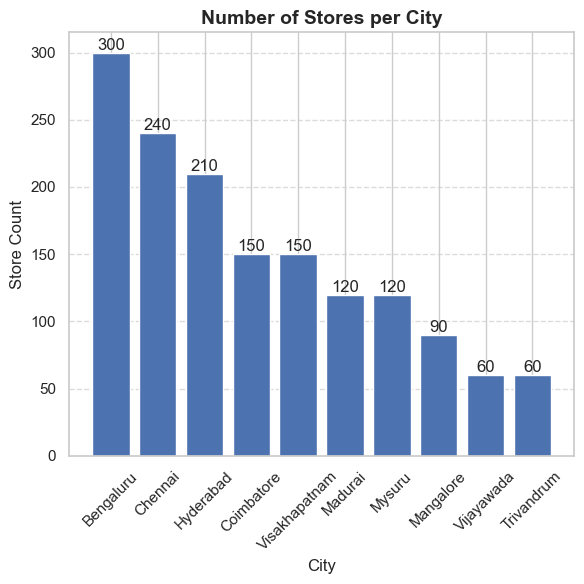

In [41]:
import matplotlib.pyplot as plt

city_counts = df_final['city'].value_counts()

plt.figure(figsize=(6,6))

bars = plt.bar(city_counts.index, city_counts.values)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}', ha='center', va='bottom')

plt.title("Number of Stores per City", fontsize=14, fontweight='bold')
plt.xlabel("City", fontsize=12)
plt.ylabel("Store Count", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Number of Stores per City.png", bbox_inches='tight')
plt.show()


# Insight

- Bengaluru has the highest number of stores.

- Chennai and Hyderabad follow but with fewer stores.

- Store distribution is uneven → indicates market focus in Bengaluru.

# Sankranti Category Contribution

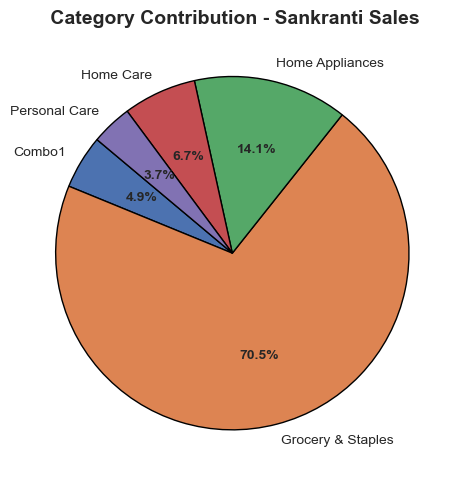

In [45]:
import matplotlib.pyplot as plt

df_san = df_final[df_final['campaign_name'] == 'Sankranti']

cat_sales = df_san.groupby('category')['quantity_sold(after_promo)'].sum()

plt.figure(figsize=(5,5))

wedges, texts, autotexts = plt.pie(
    cat_sales,
    labels=cat_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)

# Improve text readability
for text in texts:
    text.set_fontsize(10)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

plt.title(" Category Contribution - Sankranti Sales", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("category_pie.png", bbox_inches='tight')
plt.show()

# Insight

- Grocery dominates sales

- Some categories contribute very little

# Correlation: Price vs Qty Sold

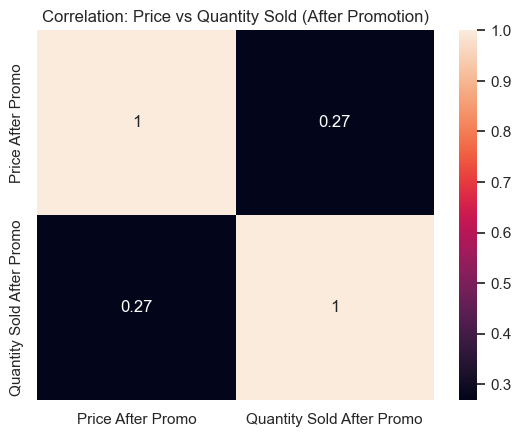

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_final[['base_price(after_promo)','quantity_sold(after_promo)']].corr()

sns.heatmap(corr, annot=True,
            xticklabels=['Price After Promo', 'Quantity Sold After Promo'],
            yticklabels=['Price After Promo', 'Quantity Sold After Promo'])

plt.title("Correlation: Price vs Quantity Sold (After Promotion)")
plt.savefig("correlation.png", bbox_inches='tight')
plt.show()

# Insight

- Weak correlation between price and sales

- This suggests that simply reducing price may not always guarantee higher sales.

- Promotions & category play a bigger role than pricing


# Distribution (Before vs After Promotion)


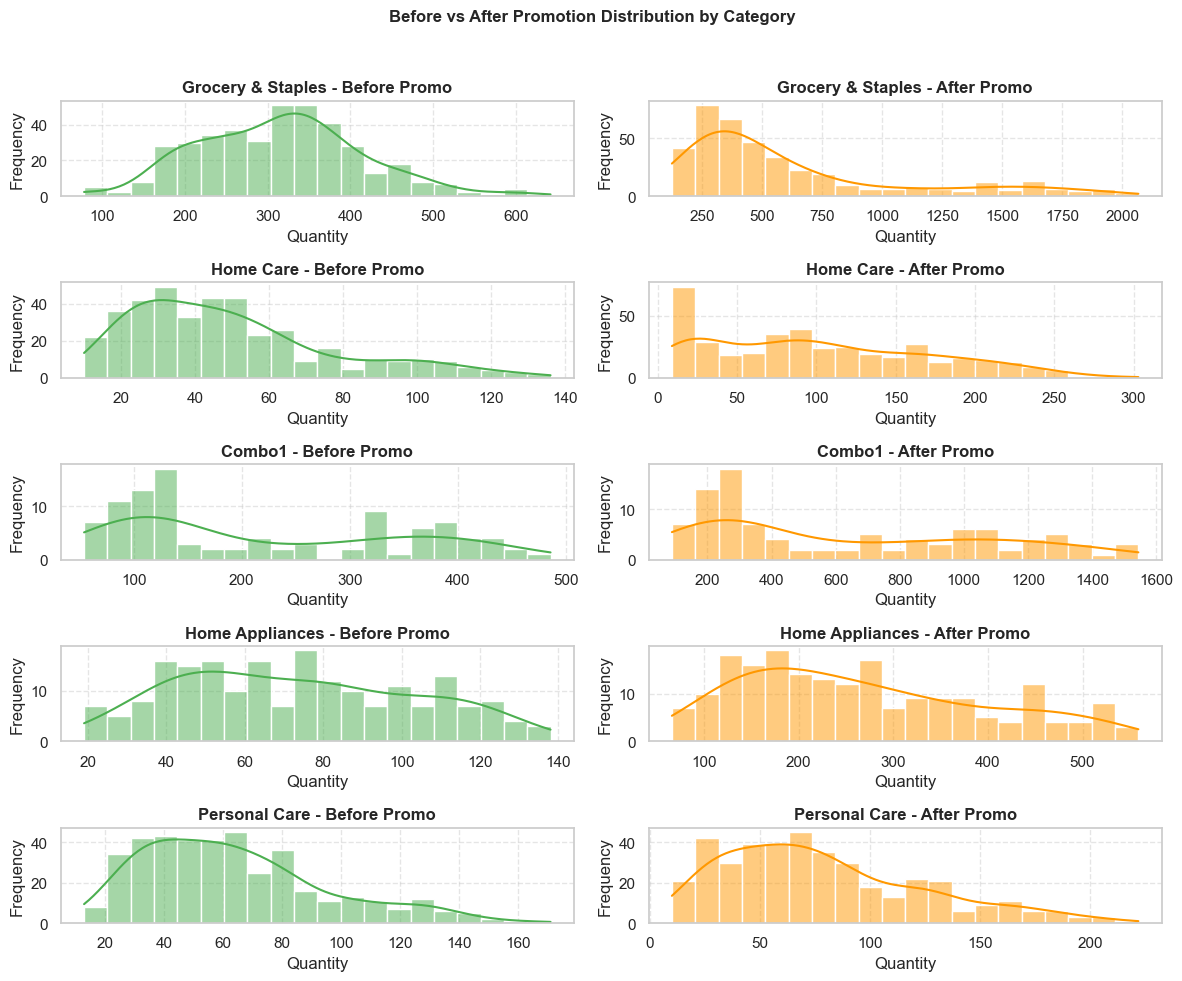

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

categories = df_final['category'].unique()

fig, axes = plt.subplots(len(categories), 2, figsize=(12, 2*len(categories)))

for i, cat in enumerate(categories):
    
    df_cat = df_final[df_final['category'] == cat]
    
    # BEFORE
    sns.histplot(
        df_cat['quantity_sold(before_promo)'],
        bins=20,
        kde=True,
        ax=axes[i, 0],
        color='#4CAF50'
    )
    axes[i, 0].set_title(f"{cat} - Before Promo", fontweight='bold')
    axes[i, 0].set_xlabel("Quantity")
    axes[i, 0].set_ylabel("Frequency")
    axes[i, 0].grid(True, linestyle='--', alpha=0.5)
    
    # AFTER
    sns.histplot(
        df_cat['quantity_sold(after_promo)'],
        bins=20,
        kde=True,
        ax=axes[i, 1],
        color='#FF9800'
    )
    axes[i, 1].set_title(f"{cat} - After Promo", fontweight='bold')
    axes[i, 1].set_xlabel("Quantity")
    axes[i, 1].set_ylabel("Frequency")
    axes[i, 1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Before vs After Promotion Distribution by Category",
             fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("distribution.png", bbox_inches='tight')
plt.show()

# Comparison (Before vs After)

- Promotions amplify existing demand (Grocery)

- Promotions also unlock demand in low-frequency categories (Appliances, Combo)

- Suggests need for category-specific promotion strategies

In [62]:
city_sales = df_final.groupby('city')['ISU%'].mean().sort_values(ascending=False)

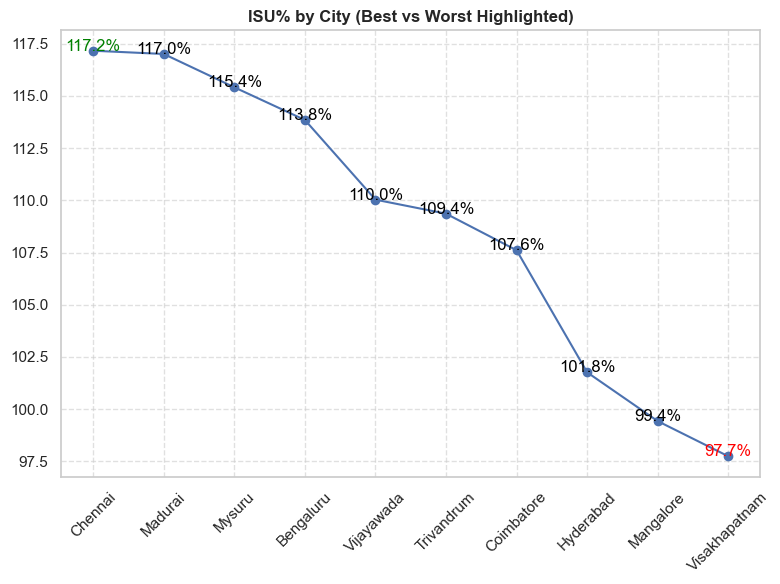

In [66]:
plt.figure(figsize=(8,6))

plt.plot(city_sales.index, city_sales.values, marker='o')

# Highlight max & min
max_idx = city_sales.idxmax()
min_idx = city_sales.idxmin()

for i, city in enumerate(city_sales.index):
    val = city_sales.loc[city]
    color = 'green' if city == max_idx else 'red' if city == min_idx else 'black'
    plt.text(i, val, f"{val:.1f}%", ha='center', color=color)

plt.title("ISU% by City (Best vs Worst Highlighted)", fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("isu_city.png", bbox_inches='tight')
plt.show()

# Insight
- Promotions are effective across all cities, but impact varies significantly

- Some cities (like Chennai and Madurai) are highly responsive to promotions

- Low-performing cities may need better targeting or different promotion strategies

# Hyderabad Promo Analysis

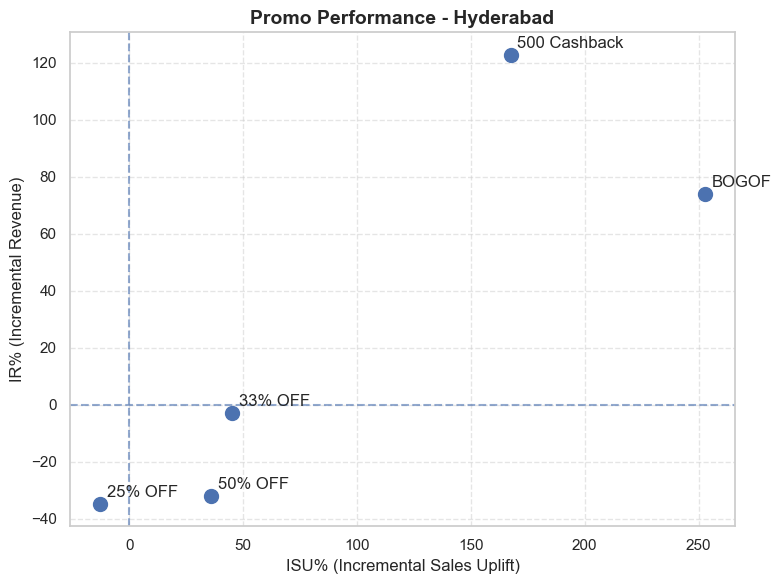

In [75]:
import matplotlib.pyplot as plt

df_hyd = df_final[df_final['city'] == 'Hyderabad']

promo = df_hyd.groupby('promo_type').agg({
    'before_rev':'sum',
    'after_rev':'sum',
    'quantity_sold(before_promo)':'sum',
    'quantity_sold(after_promo)':'sum'
})

promo['IR%'] = ((promo['after_rev'] - promo['before_rev']) / promo['before_rev']) * 100
promo['ISU%'] = ((promo['quantity_sold(after_promo)'] - promo['quantity_sold(before_promo)']) /
                 promo['quantity_sold(before_promo)']) * 100

plt.figure(figsize=(8,6))

plt.scatter(promo['ISU%'], promo['IR%'], s=100)

# Add annotations
for i, txt in enumerate(promo.index):
    plt.annotate(
        txt,
        (promo['ISU%'].iloc[i], promo['IR%'].iloc[i]),
        textcoords="offset points",
        xytext=(5,5)
    )

# Add reference lines (VERY IMPORTANT)
plt.axhline(0, linestyle='--', alpha=0.6)
plt.axvline(0, linestyle='--', alpha=0.6)

plt.title("Promo Performance - Hyderabad",
          fontsize=14, fontweight='bold')

plt.xlabel("ISU% (Incremental Sales Uplift)", fontsize=12)
plt.ylabel("IR% (Incremental Revenue)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("promo_hyderabad.png", bbox_inches='tight')
plt.show()

# Insight

- BOGOF is best for volume growth, while Cashback is better for revenue growth

- Discount-based promotions (25% & 50% OFF) are ineffective and reduce performance

- Different promo types serve different business objectives (volume vs revenue)

# Revenue Impact of Promotions — Bengaluru

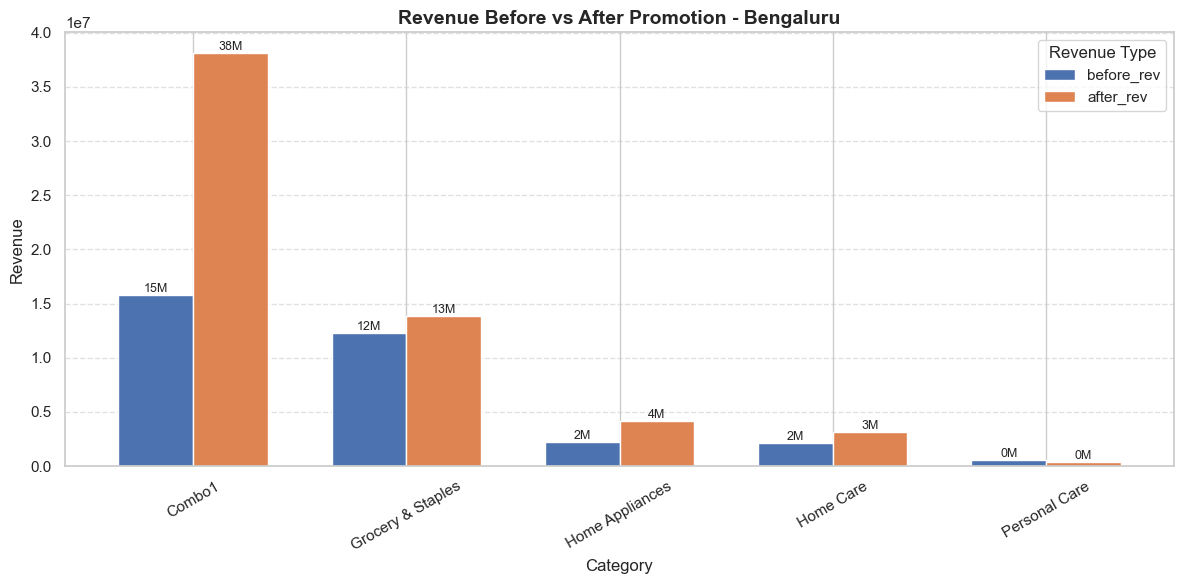

In [79]:
import matplotlib.pyplot as plt

df_blr = df_final[df_final['city'] == 'Bengaluru']

cat_rev = df_blr.groupby('category')[['before_rev','after_rev']].sum()

# Sort by after revenue (better storytelling)
cat_rev = cat_rev.sort_values('after_rev', ascending=False)

ax = cat_rev.plot(
    kind='bar',
    figsize=(12,6),
    width=0.7
)

# Add value labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height/1e6)}M',   # show in millions
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.title("Revenue Before vs After Promotion - Bengaluru",
          fontsize=14, fontweight='bold')

plt.xlabel("Category", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.legend(title="Revenue Type")
plt.tight_layout()
plt.savefig("Revenue Before vs After Promotion - Bengaluru.png", bbox_inches='tight')
plt.show()

# Insight

- Promotions are highly effective in driving revenue in Bengaluru

- Combo offers are most impactful in boosting revenue

- High-demand categories benefit the most from promotions

- Low-performing categories need better targeting strategies

# Conclusion

 Promotional campaigns had a significant impact on both revenue and product demand, with the Diwali campaign clearly outperforming Sankranti across all key metrics. Diwali generated a substantial revenue increase (approximately +79M) and drove higher sales volumes, indicating stronger customer engagement during this period.

 Additionally, promotion types played a critical role in influencing customer behavior. High-value offers such as BOGOF and cashback deals resulted in the most pronounced increase in sales, suggesting that customers respond more strongly to perceived value-driven promotions rather than standard percentage discounts.

 Overall, the analysis highlights the importance of strategic campaign timing and promotion design in maximizing sales performance.